# 04224 — Lập trình cho Trí tuệ nhân tạo và Khoa học dữ liệu
## Tuần 2 — Bài thực hành trên lớp
### Trực quan hóa dữ liệu; xử lý dữ liệu thiếu và nhiễu

**Trường Đại học Hùng Vương TP. Hồ Chí Minh — Khoa Kỹ thuật Công nghệ**

| | |
|---|---|
| **Chuẩn đầu ra** | CLO2 (trực quan hóa), CLO3 (làm sạch và chuẩn bị dữ liệu), CLO4 (phân tích và diễn giải) |
| **Thời lượng** | 3 tiết (~150 phút) — thực hành có giám sát tại phòng máy |
| **Môi trường** | Jupyter Notebook / JupyterLab |
| **Dữ liệu** | `../lab_data/sinhvien.csv`, `../lab_data/banhang_raw.csv` |

**Cuối buổi bạn nộp bốn thứ**

1. Chính notebook này, **đã chạy từ trên xuống dưới không lỗi** (Kernel → Restart Kernel and Run All Cells).
2. `tuan02_6bieudo.png` — bảng 6 biểu đồ, lưu ở 300 dpi.
3. `banhang_sach.csv` — tệp bán hàng đã làm sạch.
4. **Nhật ký làm sạch** — ô markdown ở cuối Task 3, mỗi quyết định đi kèm một lý do.

**Phân bổ thời gian**

| Task | Nội dung | Thời gian |
|:--:|---|:--:|
| 1 | Bảng 6 biểu đồ có nhãn đầy đủ | ~35 phút |
| 2 | Hàm `profile(df)` dùng lại được | ~25 phút |
| 3 | Làm sạch `banhang_raw.csv` | ~60 phút |
| 4 | So sánh ba chiến lược điền khuyết | ~30 phút |
| + | Mở rộng (tự chọn) — Seaborn | nếu còn thời gian |

> **Nguyên tắc xuyên suốt buổi hôm nay.** Mọi thao tác làm sạch là một **quyết định phân tích**, không phải một bước dọn dẹp tùy hứng. Một quyết định không ghi lại được thì không lặp lại được; không lặp lại được thì không bảo vệ được trước người đọc báo cáo.

---
## 0. Chuẩn bị

Chạy ô dưới đây trước tiên. Nếu nó báo `FileNotFoundError`, notebook của bạn đang nằm sai chỗ: nó phải ở trong thư mục `lab_exercises/`, **ngang hàng** với `lab_data/`.

**Kết quả mong đợi**

```
sinhvien.csv    : (1200, 9)
banhang_raw.csv : (928, 8)
```

In [1]:
# --- Thư viện dùng chung cho cả buổi thực hành ---
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.30

print("pandas", pd.__version__, "| numpy", np.__version__,
      "| matplotlib", matplotlib.__version__, "| seaborn", sns.__version__)

DATA_DIR = "../lab_data"

def load_csv(filename):
    """Đọc một CSV trong ../lab_data/ và báo lỗi rõ ràng nếu không tìm thấy."""
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(
            "Không tìm thấy '" + path + "'.\n"
            "Thư mục làm việc hiện tại: " + os.getcwd() + "\n"
            "Notebook phải nằm trong lab_exercises/, ngang hàng với thư mục lab_data/."
        )
    return pd.read_csv(path)

sv  = load_csv("sinhvien.csv")       # 1200 x 9
raw = load_csv("banhang_raw.csv")    # 928 x 8
print("sinhvien.csv    :", sv.shape)
print("banhang_raw.csv :", raw.shape)

pandas 3.0.6 | numpy 2.5.3 | matplotlib 3.11.2 | seaborn 0.13.2
sinhvien.csv    : (1200, 9)
banhang_raw.csv : (928, 8)


---
# Task 1 — Bảng 6 biểu đồ (~35 phút)

**Mục tiêu.** Từ `sinhvien.csv`, dựng **sáu** biểu đồ trong **một** figure `2 x 3` và lưu ở chất lượng in ấn.

**Sáu ô, đúng thứ tự này**

| Ô | Vị trí | Biểu đồ | Dữ liệu |
|:--:|:--:|---|---|
| 1 | `axes[0,0]` | Histogram | phân phối `gpa` |
| 2 | `axes[0,1]` | Box plot | `gpa` tách theo `khoa` |
| 3 | `axes[0,2]` | Scatter | `gio_tu_hoc` (trục X) và `gpa` (trục Y) |
| 4 | `axes[1,0]` | Bar | số sinh viên theo `khoa` |
| 5 | `axes[1,1]` | Line | số sinh viên nhập học theo `ngay_nhap_hoc` |
| 6 | `axes[1,2]` | Heatmap | ma trận tương quan các cột số |

**Các bước**

1. Bỏ các dòng thiếu `gpa` trước khi vẽ ô 1–3 (`dropna`), và ghi số `n` thực tế vào title.
2. Vẽ từng ô bằng API hướng đối tượng: `ax = axes[0, 0]` rồi `ax.hist(...)` — **không** dùng `plt.hist(...)`.
3. Mỗi ô phải có `set_xlabel`, `set_ylabel`, `set_title`, và nhãn trục phải ghi cả **đơn vị**.
4. Ô 6 là ngoại lệ có lý do: tên biến nằm trên tick của hai trục, còn đơn vị nằm ở **colorbar** — nên colorbar bắt buộc có nhãn.
5. Lưu: `fig.savefig(FIG_FILE, dpi=300, bbox_inches="tight")`.

> **Nói thẳng: một trục không có nhãn là một LỖI, không phải một lựa chọn thẩm mỹ.** "GPA" chưa đủ — người đọc không biết 3.2 là cao hay thấp nếu không biết thang điểm. Phải là "GPA (thang điểm 4.0)". Ô tự kiểm tra bên dưới sẽ bắt lỗi này.

**Kết quả mong đợi**

- Ô tự kiểm tra in `Task 1 ĐẠT: ...`
- File `tuan02_6bieudo.png` tồn tại, khoảng **0.9–1.0 MB** (nếu chỉ vài chục KB thì bạn quên `dpi=300`).
- Ô 1: phân phối gần chuẩn, đỉnh quanh **2.6**, n = **1145**.
- Ô 3: tương quan `r ≈ 0.23` — dương nhưng **yếu**; 1145 điểm chồng nhau nên phải dùng `alpha`.
- Ô 6: `nam_hoc`–`gpa` ≈ **0.26**, `gio_tu_hoc`–`gpa` ≈ **0.23**, `so_tin_chi` gần như không tương quan với gì.

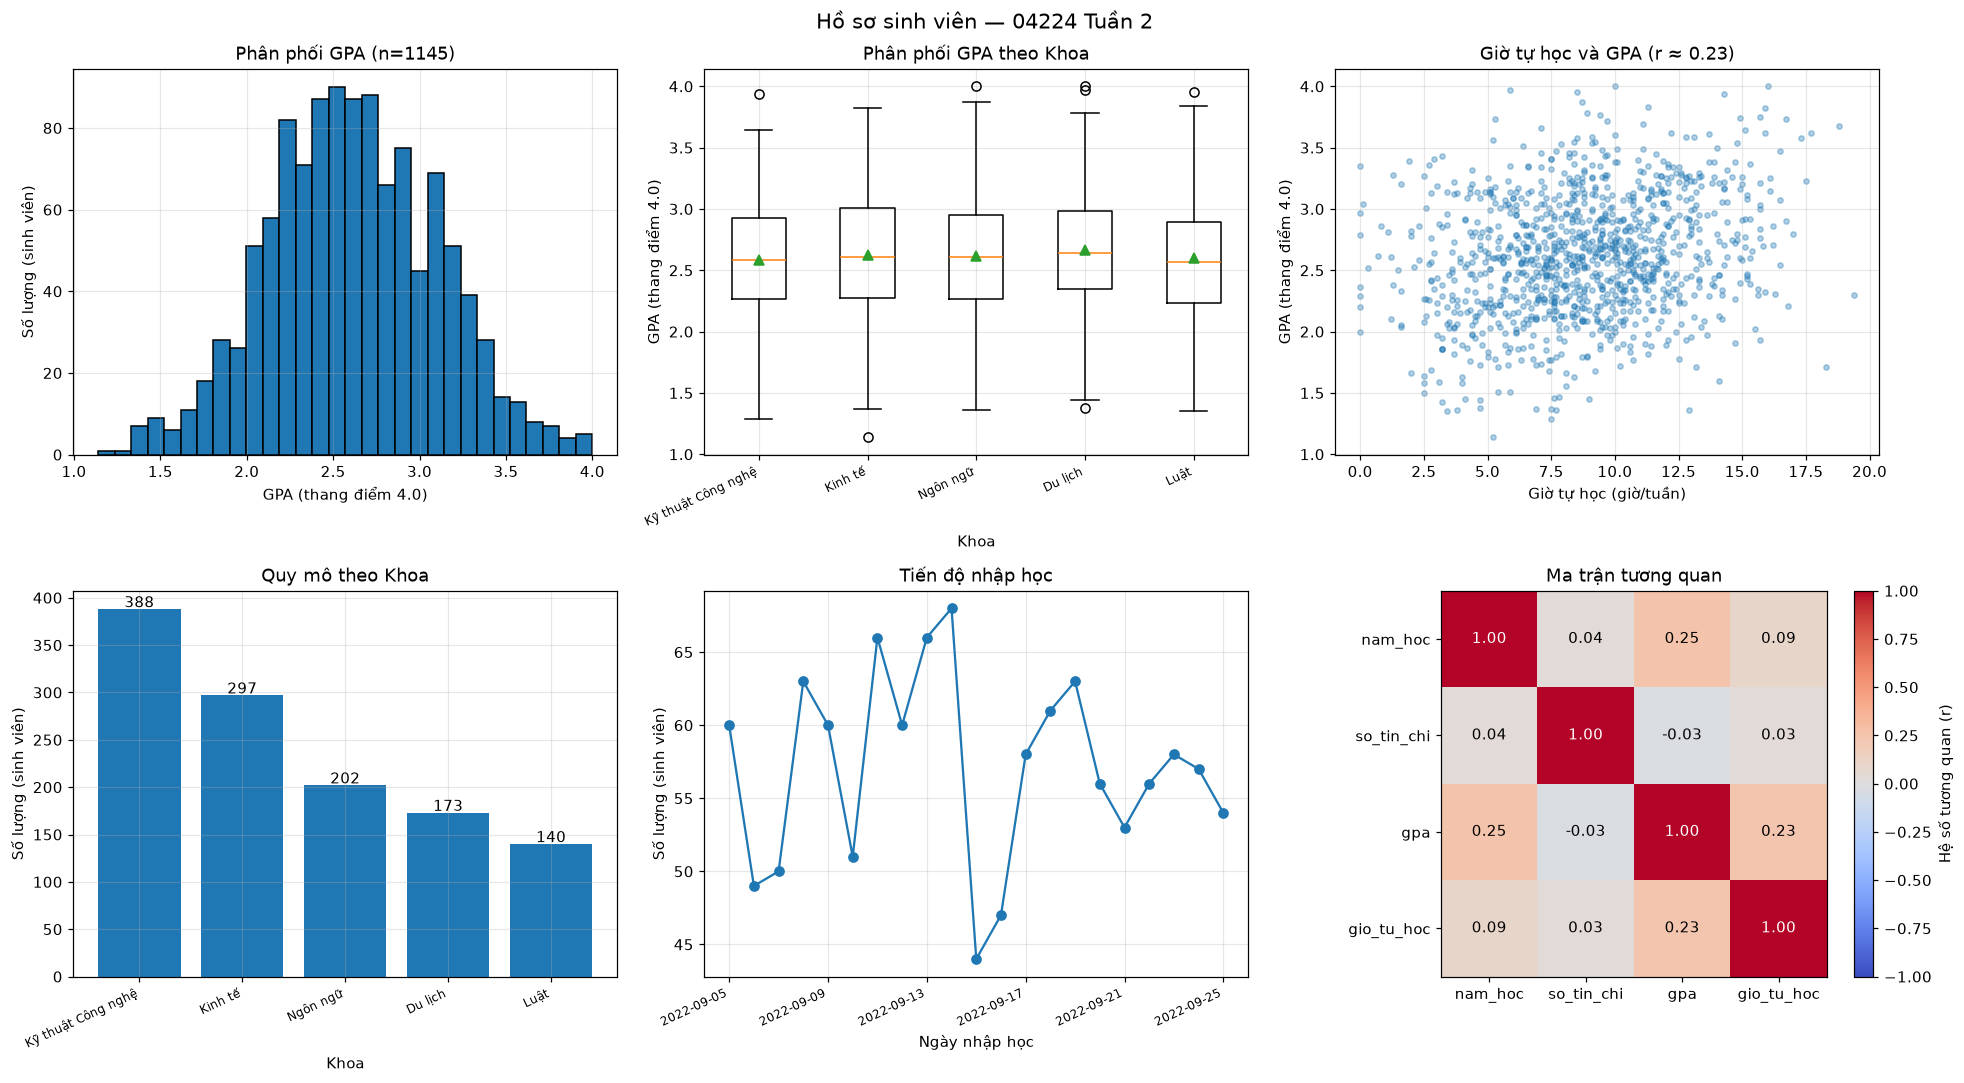

In [2]:
FIG_FILE = "tuan02_6bieudo.png"
sv_gpa = sv.dropna(subset=["gpa"])          # 1145 dòng có GPA

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# (1) Histogram — phân phối GPA -------------------------------------------
ax = axes[0, 0]
# TODO: ax.hist(...) với bins=30
# TODO: set_xlabel / set_ylabel / set_title — nhãn phải ghi cả ĐƠN VỊ
ax.hist(sv_gpa["gpa"], bins=30, edgecolor="black")
ax.set_xlabel("GPA (thang điểm 4.0)")
ax.set_ylabel("Số lượng (sinh viên)")
ax.set_title(f"Phân phối GPA (n={len(sv_gpa)})")

# (2) Box plot — GPA theo khoa --------------------------------------------
ax = axes[0, 1]
faculties = sv["khoa"].value_counts().index.tolist()
# TODO: ax.boxplot([...], tick_labels=faculties, showmeans=True)
#       Gợi ý: dựng list GPA của từng khoa bằng list comprehension trên `faculties`.
# TODO: nhãn + title
data = [sv[sv["khoa"] == f]["gpa"].dropna() for f in faculties]
ax.boxplot(data, tick_labels=faculties, showmeans=True)
ax.set_xlabel("Khoa")
ax.set_ylabel("GPA (thang điểm 4.0)")
ax.set_title("Phân phối GPA theo Khoa")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)

# (3) Scatter — giờ tự học và GPA -----------------------------------------
ax = axes[0, 2]
d3 = sv.dropna(subset=["gpa", "gio_tu_hoc"])
# TODO: ax.scatter(...). 1145 điểm sẽ chồng lên nhau -> dùng s=12, alpha=0.35
# TODO: tính r = d3["gio_tu_hoc"].corr(d3["gpa"]) và đưa vào title
# TODO: nhãn + title
ax.scatter(d3["gio_tu_hoc"], d3["gpa"], s=12, alpha=0.35)
r = d3["gio_tu_hoc"].corr(d3["gpa"])
ax.set_xlabel("Giờ tự học (giờ/tuần)")
ax.set_ylabel("GPA (thang điểm 4.0)")
ax.set_title(f"Giờ tự học và GPA (r ≈ {r:.2f})")

# (4) Bar — số sinh viên theo khoa ----------------------------------------
ax = axes[1, 0]
counts = sv["khoa"].value_counts()
# TODO: ax.bar(...)
# TODO: ghi con số lên đầu mỗi cột bằng ax.text(...)
# TODO: nhãn + title
ax.bar(counts.index, counts.values)
for i, v in enumerate(counts.values):
    ax.text(i, v + 2, str(v), ha="center")
ax.set_xlabel("Khoa")
ax.set_ylabel("Số lượng (sinh viên)")
ax.set_title("Quy mô theo Khoa")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)

# (5) Line — lượng nhập học theo ngày -------------------------------------
ax = axes[1, 1]
# TODO: enrol = pd.to_datetime(sv["ngay_nhap_hoc"]).value_counts().sort_index()
# TODO: ax.plot(..., marker="o")
# TODO: nhãn + title
enrol = pd.to_datetime(sv["ngay_nhap_hoc"]).value_counts().sort_index()
ax.plot(enrol.index, enrol.values, marker="o")
ax.set_xlabel("Ngày nhập học")
ax.set_ylabel("Số lượng (sinh viên)")
ax.set_title("Tiến độ nhập học")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)

# (6) Heatmap — ma trận tương quan ----------------------------------------
ax = axes[1, 2]
num_cols = ["nam_hoc", "so_tin_chi", "gpa", "gio_tu_hoc"]
# TODO: M = sv[num_cols].corr().to_numpy()
# TODO: im = ax.imshow(M, cmap="coolwarm", vmin=-1, vmax=1)
# TODO: đặt tên biến lên cả hai trục bằng set_xticks/set_xticklabels và set_yticks/set_yticklabels
# TODO: ghi giá trị vào từng ô bằng hai vòng for lồng nhau + ax.text(...)
# TODO: title, và ax.grid(False) cho heatmap
# TODO: cbar = fig.colorbar(im, ax=ax, fraction=0.046)  rồi cbar.set_label(...)
#       Ở ô này, ĐƠN VỊ nằm trên colorbar chứ không nằm trên trục -> colorbar bắt buộc có nhãn.
M = sv[num_cols].corr().to_numpy()
im = ax.imshow(M, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)))
ax.set_xticklabels(num_cols)
ax.set_yticks(range(len(num_cols)))
ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", 
                color="white" if abs(M[i, j]) > 0.5 else "black")
ax.grid(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.046)
cbar.set_label("Hệ số tương quan (r)")
ax.set_title("Ma trận tương quan")

fig.suptitle("Hồ sơ sinh viên — 04224 Tuần 2", fontsize=14)
fig.tight_layout()
# TODO: lưu hình — fig.savefig(FIG_FILE, dpi=300, bbox_inches="tight")
fig.savefig(FIG_FILE, dpi=300, bbox_inches="tight")
plt.show()

In [3]:
# --- Tự kiểm tra Task 1: trục không nhãn là một LỖI, không phải lựa chọn thẩm mỹ ---
assert axes.shape == (2, 3), "Phải là lưới 2x3"

for i, a in enumerate(axes.flat, 1):
    assert a.get_title().strip() != "", "Ô số %d chưa có title" % i

for i, a in enumerate(list(axes.flat)[:5], 1):
    assert a.get_xlabel().strip() != "", "Ô số %d chưa có nhãn trục X" % i
    assert a.get_ylabel().strip() != "", "Ô số %d chưa có nhãn trục Y" % i

# Ô số 6 là heatmap: tên biến nằm trên tick, còn đơn vị nằm ở colorbar
heat = axes[1, 2]
assert any(t.get_text().strip() for t in heat.get_xticklabels()), \
    "Heatmap chưa đặt tên biến lên trục"
extra_axes = [a for a in fig.axes if a not in list(axes.flat)]
assert extra_axes, "Heatmap chưa có colorbar"
assert any(a.get_ylabel().strip() for a in extra_axes), "Colorbar chưa có nhãn"

assert os.path.exists(FIG_FILE), "Chưa lưu file hình"
assert os.path.getsize(FIG_FILE) > 200_000, "File quá nhỏ — có chắc đã dùng dpi=300 chưa?"
print("Task 1 ĐẠT: 6 biểu đồ, đủ title + nhãn trục + colorbar có nhãn, hình 300 dpi đã lưu.")

Task 1 ĐẠT: 6 biểu đồ, đủ title + nhãn trục + colorbar có nhãn, hình 300 dpi đã lưu.


### Nhận định của bạn — mỗi biểu đồ một câu

> *(Nhấp đúp vào ô này để sửa. Một câu cho mỗi ô, nói **điều biểu đồ cho biết**, không mô tả lại hình dạng. "Phân phối hình chuông" không phải nhận định; "GPA tập trung quanh 2.6, rất ít sinh viên trên 3.5" mới là nhận định.)*

1. Histogram GPA: Điểm GPA của sinh viên chủ yếu tập trung trong khoảng từ 2.3 đến 3.0, với đỉnh cao nhất rơi vào mức 2.6.
2. Box plot theo khoa: Sinh viên khoa Kỹ thuật Công nghệ có dải điểm GPA biến thiên rộng nhất và xuất hiện một sinh viên có điểm ngoại lai rất thấp (gần 1.0).
3. Scatter giờ tự học – GPA: Không có mối quan hệ tuyến tính rõ rệt nào giữa số giờ tự học và điểm GPA, bởi vì sinh viên học ít hay nhiều giờ thì điểm vẫn trải đều ở các mức (r ≈ 0.23, mức độ tương quan rất yếu).
4. Bar quy mô khoa: Khoa Kỹ thuật Công nghệ có quy mô sinh viên đông nhất với 388 người, cao gấp gần 3 lần so với khoa Luật (140 người).
5. Line nhập học: Quá trình nhập học không diễn ra đều đặn mà dao động rất mạnh, với đỉnh điểm lượng sinh viên nhập học đông nhất rơi vào khoảng giữa tháng 9.
6. Heatmap tương quan: Năm học và số giờ tự học có tác động đồng biến nhẹ đến điểm GPA (hệ số tương quan lần lượt là 0.25 và 0.23), trong khi số tín chỉ gần như không có mối liên hệ nào với GPA.

---
# Task 2 — Hàm `profile(df)` (~25 phút)

**Mục tiêu.** Viết **một** hàm dùng được cho **mọi** DataFrame, trả về cho từng cột:

| Trường | Ý nghĩa |
|---|---|
| `dtype` | kiểu dữ liệu pandas đang hiểu |
| `n_missing` | số ô thiếu |
| `pct_missing` | tỉ lệ thiếu, tính theo % |
| `n_unique` | số giá trị duy nhất (không tính `NaN`) |
| `top_values` | 5 giá trị phổ biến nhất kèm số đếm |

**Các bước**

1. Hàm trả về một **DataFrame** (không phải `dict`, không phải chuỗi `print`) — để còn lọc, sắp xếp và đem đi dùng lại.
2. Index là tên cột, và **thứ tự cột phải giữ nguyên như trong `df`**.
3. Chạy trên cả `sinhvien.csv` lẫn `banhang_raw.csv`.
4. Hàm phải chịu được trường hợp biên: cột toàn `NaN`, và DataFrame rỗng (`len(df) == 0` — đừng chia cho 0).
5. `assert len(profile(df)) == df.shape[1]` — đúng một dòng cho mỗi cột.

> `df.describe()` **không** thay thế được hàm này: nó bỏ qua cột chuỗi và không cho biết tỉ lệ thiếu. Bạn sẽ dùng lại `profile()` ở Task 3 và ở các tuần sau.

**Kết quả mong đợi**

- `profile(sv)` — **9 dòng**. `gpa` thiếu **55 (4.58%)**, `gio_tu_hoc` thiếu **53 (4.42%)**, `tinh_tp` thiếu **14 (1.17%)**.
- `profile(raw)` — **8 dòng**, và bảng này đã đủ để lộ **bốn** khuyết tật trước khi bạn sửa dòng nào:

| Dấu hiệu trong bảng | Khuyết tật |
|---|---|
| `ma_don` có `n_unique = 900` nhưng `raw` có **928** dòng | có dòng trùng lặp |
| `kenh` có `n_unique = 4` | 4 cách viết cho 2 kênh thật |
| `thanh_tien` có `dtype = str` | số đang lưu dưới dạng chuỗi |
| `so_luong` có `dtype = float64` dù là số nguyên | có `NaN` nên pandas phải nới kiểu |

- Ô tự kiểm tra in `Task 2 ĐẠT: ...`

In [4]:
def profile(df, k=5):
    """Hồ sơ nhanh của một DataFrame bất kỳ — mỗi cột một dòng.

    Trả về DataFrame có index là tên cột và các cột:
    dtype, n_missing, pct_missing, n_unique, top_values
    """
    n = len(df)
    rows = []
    for col in df.columns:
        s = df[col]
        # TODO: vc = k giá trị phổ biến nhất của s   (gợi ý: s.value_counts().head(k))
        # TODO: top = chuỗi mô tả vc, ví dụ "'Online' x510, 'Cửa hàng' x279"
        #       Nhớ trường hợp cột rỗng hoặc toàn NaN -> vc rỗng.
        vc = s.value_counts(dropna=True).head(k)
        top = ", ".join([f"{repr(k)} x{v}" for k, v in vc.items()])
        
        n_missing = int(s.isna().sum())
        pct_missing = round((n_missing / n * 100), 2) if n > 0 else 0.0
        n_unique = s.nunique(dropna=True)
        rows.append({
            "column":      col,
            "dtype":       str(s.dtype),
            "n_missing":   n_missing,   # TODO: số ô thiếu, kiểu int
            "pct_missing": pct_missing,   # TODO: tỉ lệ thiếu tính theo %, làm tròn 2 chữ số.
                                #       Cẩn thận: n có thể bằng 0 -> đừng chia cho 0.
            "n_unique":    n_unique,   # TODO: số giá trị duy nhất (không tính NaN)
            "top_values":  top,   # TODO: dùng `top` ở trên
        })
    return pd.DataFrame(rows, columns=["column", "dtype", "n_missing",
                                    "pct_missing", "n_unique",
                                    "top_values"]).set_index("column")

In [5]:
# --- Chạy trên cả hai tập dữ liệu ---
print("=" * 28, "sinhvien.csv", "=" * 28)
p_sv = profile(sv)
print(p_sv)

print()
print("=" * 28, "banhang_raw.csv", "=" * 28)
p_raw = profile(raw)
print(p_raw)

# --- Tự kiểm tra: đúng một dòng cho mỗi cột ---
assert len(p_sv) == sv.shape[1], "profile() phải trả về đúng 1 dòng cho 1 cột"
assert len(p_raw) == raw.shape[1], "profile() phải trả về đúng 1 dòng cho 1 cột"
assert list(p_sv.index) == list(sv.columns), "Thứ tự cột phải giữ nguyên"

# --- Phải chạy được với DataFrame BẤT KỲ, kể cả trường hợp biên ---
edge = pd.DataFrame({"a": [1, 1, 2], "b": [np.nan] * 3, "c": ["x", None, "x"]})
p_edge = profile(edge)
assert len(p_edge) == 3
assert p_edge.loc["b", "n_missing"] == 3 and p_edge.loc["b", "n_unique"] == 0
assert profile(pd.DataFrame(columns=["z"])).shape[0] == 1   # DataFrame rỗng
print("\nTask 2 ĐẠT: đúng 1 dòng/cột, chịu được cột toàn NaN và DataFrame rỗng.")

============================ sinhvien.csv ============================
                 dtype  n_missing  pct_missing  n_unique                                         top_values
column                                                                                                     
mssv             int64          0         0.00      1200  2200001 x1, 2200002 x1, 2200003 x1, 2200004 x1...
ho_ten             str          0         0.00       861  'Phạm Thị Dũng' x5, 'Hoàng Ngọc Sơn' x5, 'Huỳn...
khoa               str          0         0.00         5  'Kỹ thuật Công nghệ' x388, 'Kinh tế' x297, 'Ng...
nam_hoc          int64          0         0.00         4                     1 x361, 2 x318, 3 x285, 4 x236
tinh_tp            str         14         1.17         8  'TP. Hồ Chí Minh' x492, 'Hà Nội' x146, 'Đà Nẵn...
so_tin_chi       int64          0         0.00        13         23 x103, 24 x103, 19 x103, 16 x101, 18 x98
gpa            float64         55         4.58       226    2.61 

### Trước khi sang Task 3 — đọc bảng, đừng đọc dữ liệu thô

> *(Nhấp đúp để sửa.)*

1. Cột nào của `banhang_raw.csv` có `dtype` **không đúng với ý nghĩa thực tế** của nó? Vì sao pandas lại hiểu như vậy? 
Có 3 cột có kiểu dữ liệu không đúng với thực tế:   

thanh_tien: Đang là str (chuỗi), nhưng thực tế phải là số (numeric) để tính toán. Pandas hiểu là chuỗi vì dữ liệu bị lẫn các ký tự không phải là số (ví dụ chữ "đ" hoặc dấu chấm/phẩy phân cách).

so_luong: Đang là float64 (số thực), nhưng số lượng sản phẩm thì phải là số nguyên (int). Pandas đổi sang số thực vì cột này có 30 giá trị bị thiếu (NaN), và pandas mặc định ép kiểu số nguyên có chứa NaN thành float.

ngay: Đang là str (chuỗi), thực tế cần là kiểu ngày tháng (datetime). Pandas hiểu là chuỗi vì định dạng ngày bị trộn lẫn (VD: có cả YYYY-MM-DD và DD/MM/YYYY) hoặc có chứa ngày không hợp lệ (như '31/02/2024').

2. `ma_don` có bao nhiêu giá trị duy nhất, và tệp có bao nhiêu dòng? Hai con số đó cho bạn biết điều gì? 
Cột ma_don có 900 giá trị duy nhất.   

Tuy nhiên, tổng số dòng của tệp là 928 (có thể tính ngược từ cột so_luong: 30 ô thiếu tương đương 3.23% tổng số dòng => ~928 dòng).   

Điều này cho biết: Dữ liệu đang có hiện tượng trùng lặp. Có 28 dòng thừa mang mã đơn hàng đã tồn tại.
3. Cột `kenh` có bao nhiêu giá trị duy nhất, và theo bạn **thực tế** có bao nhiêu kênh bán hàng? 
Cột kenh hiện đang báo có 4 giá trị duy nhất (bao gồm: 'Online', 'Cửa hàng', 'ONLINE', 'Cua hang'...).

Thực tế: Chỉ có 2 kênh bán hàng cốt lõi (Trực tuyến và Tại cửa hàng). Việc xuất hiện thành 4 kênh là do lỗi nhập liệu không nhất quán (nhập viết hoa/viết thường lộn xộn hoặc gõ thiếu dấu tiếng Việt).

---
# Task 3 — Làm sạch `banhang_raw.csv` (~60 phút)

Đây là bài trọng tâm của buổi. Tệp này **cố ý bị làm bẩn** theo đúng những kiểu lỗi bạn sẽ gặp ngoài thực tế: xuất từ nhiều nguồn, nhiều người nhập, nhiều định dạng địa phương.

**Quy tắc làm việc**

1. **Soi trước, sửa sau.** Đừng gõ `drop_duplicates()` ở dòng đầu tiên. Lập hồ sơ, tìm cho hết vấn đề, rồi mới sửa.
2. **Đừng xóa dòng khi chưa cần.** Một ô hỏng không làm hỏng bảy ô còn lại của cùng một dòng.
3. **Mỗi bước là một quyết định.** Ghi ngay vào nhật ký ở cuối Task 3, đừng để đến cuối buổi mới nhớ lại.

**Bảng kết quả mong đợi — dùng để tự chấm**

| Bước | Việc | Kết quả mong đợi |
|:--:|---|---|
| 3.1 | Nạp và lập hồ sơ | `(928, 8)`; 28 dòng trùng; `kenh` 4 cách viết; `thanh_tien` 166 dòng chuỗi; `ngay` 120 dòng DD/MM |
| 3.2 | Bỏ trùng lặp | bỏ **28** dòng → còn **900**; `ma_don` duy nhất |
| 3.3 | Chuẩn hóa `kenh` | 4 → **2** nhãn: `Online` **570**, `Cửa hàng` **330** |
| 3.4 | `thanh_tien` sang số | `dtype` `str` → `int64`; tổng **3.068.440.000 đ**; min 250.000, max 16.000.000 |
| 3.5 | Phân tích `ngay` | 785 dòng ISO + 115 dòng DD/MM; **7 NaT**, đều là `31/02/2024`; khoảng 2024-01-01 → 2024-12-29 |
| 3.6 | Xử lý thiếu | `so_luong` **30 → 0**; `tinh_tp` **52 → 0** (9 nhãn) |
| 3.7 | Xử lý ngoại lai | IQR gắn cờ **7** dòng (4 dòng `500`, 3 dòng `-2`) → `so_luong` còn ∈ [1, 5], `int64` |
| 3.8 | Kiểm chứng chéo | **0/900** dòng lệch giữa `so_luong × don_gia` và `thanh_tien` |

**Kết quả cuối cùng.** `(900, 8)`, đúng **7** ô thiếu trên toàn bảng (cả 7 đều ở cột `ngay`), và tệp `banhang_sach.csv` đã lưu.

> Một gợi ý duy nhất, và là gợi ý quan trọng nhất của buổi: **cột `thanh_tien` không chỉ là dữ liệu, nó còn là bằng chứng.** Hãy nghĩ xem nó có quan hệ gì với `so_luong` và `don_gia`, và quan hệ đó giúp được gì ở bước 3.6 và 3.7.

## 3.1 — Nạp và lập hồ sơ: tìm cho hết vấn đề trước khi sửa

Dùng lại `profile()` của Task 2. Sau đó đếm riêng bốn thứ: dòng trùng, cách viết của `kenh`, số dòng `thanh_tien` còn chữ `đ`, số dòng `ngay` theo định dạng `DD/MM/YYYY`.

**Kết quả mong đợi.** `(928, 8)` · **28** dòng trùng · `kenh`: `'Online'` 510, `'Cửa hàng'` 279, `'ONLINE'` 78, `'Cua hang'` 61 · **166** dòng `thanh_tien` dạng chuỗi · **120** dòng `ngay` dạng DD/MM.

In [6]:
# --- 3.1 Nạp và soi kỹ TRƯỚC khi sửa bất cứ thứ gì ---
df = load_csv("banhang_raw.csv")
print("Kích thước:", df.shape)
print()
print(profile(df))          # dùng lại hàm vừa viết ở Task 2
print()

# TODO: đếm số dòng trùng lặp hoàn toàn        -> df.duplicated().sum()
print("Số dòng trùng lặp hoàn toàn:", df.duplicated().sum())
# TODO: liệt kê các cách viết của cột `kenh`    -> df["kenh"].value_counts()
#       In bằng repr() để nhìn thấy dấu cách thừa nếu có.
print("\nCác cách viết của cột 'kenh':")
for k, v in df["kenh"].value_counts(dropna=False).items():
    print(f"  {repr(k)}: {v} dòng")
# TODO: đếm số dòng `thanh_tien` còn chứa chữ "đ"
so_dong_chua_d = df["thanh_tien"].astype(str).str.contains("đ").sum()
print("\nSố dòng thanh_tien chứa chữ 'đ':", so_dong_chua_d)
# TODO: đếm số dòng `ngay` ở dạng DD/MM/YYYY   -> str.fullmatch(r"\d{2}/\d{2}/\d{4}")
so_dong_dmy = df["ngay"].astype(str).str.fullmatch(r"\d{2}/\d{2}/\d{4}").sum()
print("Số dòng ngày ở dạng DD/MM/YYYY:", so_dong_dmy)

Kích thước: (928, 8)

              dtype  n_missing  pct_missing  n_unique                                         top_values
column                                                                                                  
ma_don          str          0         0.00       900  'DH00653' x2, 'DH00888' x2, 'DH00594' x2, 'DH0...
san_pham        str          0         0.00         6  'Bàn phím' x170, 'Màn hình' x158, 'Ổ cứng SSD'...
so_luong    float64         30         3.23         7   1.0 x204, 4.0 x180, 3.0 x178, 2.0 x165, 5.0 x164
don_gia       int64          0         0.00         6  450000 x170, 3200000 x158, 1450000 x154, 89000...
kenh            str          0         0.00         4  'Online' x510, 'Cửa hàng' x279, 'ONLINE' x78, ...
tinh_tp         str         54         5.82         8  'Lâm Đồng' x122, 'TP. Hồ Chí Minh' x120, 'Cần ...
ngay            str          0         0.00       415  '31/02/2024' x7, '2024-11-11' x7, '2024-02-29'...
thanh_tien      str          0   

## 3.2 — Bỏ dòng trùng lặp hoàn toàn

Ô dưới in trước một cặp dòng trùng để bạn nhìn tận mắt: hai dòng giống nhau ở **cả tám cột**, kể cả `ma_don`. Đó là lỗi lặp khi gộp tệp, không phải hai đơn hàng khác nhau.

Phân biệt hai lệnh, vì chúng mang ý nghĩa khác nhau:
- `drop_duplicates()` — bỏ dòng giống nhau ở **mọi** cột.
- `drop_duplicates(subset="ma_don")` — bỏ dòng trùng **mã đơn**, kể cả khi các cột khác khác nhau.

Ở tệp này hai lệnh cho cùng kết quả. Nhưng nếu hai dòng cùng `ma_don` mà **khác** `so_luong` thì sao? Đó không còn là trùng lặp mà là **xung đột dữ liệu** — phải điều tra, không được lặng lẽ giữ lại một dòng.

**Kết quả mong đợi.** Bỏ **28** dòng, `928 → 900`, `ma_don` trở thành duy nhất.

In [7]:
# --- 3.2 Bỏ các dòng trùng lặp hoàn toàn ---
before = len(df)
print("Ví dụ một cặp trùng lặp (trùng cả `ma_don`):")
print(df[df.duplicated(subset="ma_don", keep=False)].sort_values("ma_don").head(4))

# TODO: df = ...            (bỏ dòng trùng, rồi .reset_index(drop=True))
df = df.drop_duplicates().reset_index(drop=True)

removed = before - len(df)
print("\nĐã bỏ %d dòng trùng lặp: %d -> %d" % (removed, before, len(df)))

assert removed == 28, "Phải bỏ đúng 28 dòng, đang bỏ %d" % removed
assert len(df) == 900, "Còn lại phải là 900 dòng"
assert df.duplicated().sum() == 0
assert df["ma_don"].is_unique, "Mỗi `ma_don` chỉ được xuất hiện một lần"

Ví dụ một cặp trùng lặp (trùng cả `ma_don`):
      ma_don    san_pham  so_luong  don_gia    kenh          tinh_tp        ngay   thanh_tien
54   DH00061    Tai nghe       4.0   690000  ONLINE         Đồng Nai  2024-11-19      2760000
296  DH00061    Tai nghe       4.0   690000  ONLINE         Đồng Nai  2024-11-19      2760000
791  DH00064  Ổ cứng SSD       2.0  1450000  Online  TP. Hồ Chí Minh  2024-02-11  2.900.000 đ
152  DH00064  Ổ cứng SSD       2.0  1450000  Online  TP. Hồ Chí Minh  2024-02-11  2.900.000 đ

Đã bỏ 28 dòng trùng lặp: 928 -> 900


## 3.3 — Chuẩn hóa `kenh` về đúng 2 nhãn

Bốn cách viết trong tệp là ba loại lỗi khác nhau, và mỗi loại cần một cách xử lý khác nhau:

| Cách viết | Loại lỗi | Công cụ |
|---|---|---|
| `Online` | chuẩn | — |
| `ONLINE` | sai hoa/thường | `.str.casefold()` |
| `Cửa hàng` | chuẩn | — |
| `Cua hang` | **mất dấu tiếng Việt** | không có hàm nào tự sửa → **ánh xạ tay** |

Thêm `.str.strip()` ở đầu chuỗi xử lý: tệp này không có dấu cách thừa, nhưng một tệp xuất từ Excel thì gần như chắc chắn có, và `.strip()` không làm hỏng gì.

**Cái bẫy.** `.str.title()` trông như lời giải nhưng không phải: `"Cua hang".title()` cho `"Cua Hang"`, vẫn khác `"Cửa hàng"`. Không có hàm chuẩn hóa nào đoán được dấu tiếng Việt — bạn phải khai báo ánh xạ.

**Vì sao `.map()` chứ không phải `.replace()`.** `map()` trả về `NaN` cho khóa không có trong từ điển. Đó là **tính năng**: nếu tuần sau tệp xuất hiện thêm một cách viết mới, `assert` bên dưới sẽ bắt được ngay. `replace()` sẽ lặng lẽ giữ nguyên giá trị lạ.

**Kết quả mong đợi.** 4 → **2** nhãn: `Online` = **570** (= 493 + 77) và `Cửa hàng` = **330** (= 272 + 58), tính trên 900 dòng còn lại sau bước 3.2. Không có `NaN`.

In [8]:
# --- 3.3 Chuẩn hoá `kenh` về đúng 2 nhãn ---
print("Trước:", ", ".join("%r x%d" % (k, v) for k, v in df["kenh"].value_counts(dropna=False).items()))

# Bẫy: .str.title() không cứu được chuỗi mất dấu
print("\nBẫy:", repr("Cua hang".title()), "!=", repr("Cửa hàng"))

# TODO: key = df["kenh"] sau khi .str.strip() rồi .str.casefold()
key = df["kenh"].str.strip().str.casefold()
# print("Sau strip + casefold còn lại:", sorted(key.unique()))

KENH_MAP = {
    # TODO: điền đủ các khoá viết thường ở trên, ánh xạ về đúng 2 nhãn
    #       "Online" và "Cửa hàng". Bản mất dấu phải ánh xạ tay.
    "online": "Online",
    "cửa hàng": "Cửa hàng",
    "cua hang": "Cửa hàng"
}

# TODO: df["kenh"] = key.map(KENH_MAP)
df["kenh"] = key.map(KENH_MAP)

print("\nSau :", ", ".join("%r x%d" % (k, v) for k, v in df["kenh"].value_counts(dropna=False).items()))
assert df["kenh"].nunique() == 2, "Phải còn đúng 2 nhãn, đang có %d" % df["kenh"].nunique()
assert df["kenh"].isna().sum() == 0, "map() sinh ra NaN -> còn chính tả chưa liệt kê trong KENH_MAP"
assert int((df["kenh"] == "Online").sum()) == 570
assert int((df["kenh"] == "Cửa hàng").sum()) == 330

Trước: 'Online' x493, 'Cửa hàng' x272, 'ONLINE' x77, 'Cua hang' x58

Bẫy: 'Cua Hang' != 'Cửa hàng'

Sau : 'Online' x570, 'Cửa hàng' x330


## 3.4 — `thanh_tien`: từ chuỗi tiền tệ sang số

162 dòng (sau khi lọc trùng) đang ghi kiểu `"2.760.000 đ"`. Ba việc phải làm trước khi ép kiểu: bỏ chữ `đ`, bỏ dấu `.`, và `.strip()`.

**Cái bẫy chết người.** Trong tiếng Việt dấu `.` là **phân cách hàng nghìn**, không phải dấu thập phân. `"2.760.000"` là hai triệu bảy trăm sáu mươi nghìn, không phải 2.76. Nếu bạn đưa thẳng chuỗi này cho `pd.to_numeric` mà không bỏ dấu chấm, kết quả sẽ sai **ba bậc độ lớn** — và không có thông báo lỗi nào.

**Cái bẫy thứ hai.** `.str.replace(".", "")` mặc định hiểu `"."` là **regex**, mà `.` trong regex nghĩa là "ký tự bất kỳ" → xóa sạch cả chuỗi. Bắt buộc `regex=False`.

**Vì sao giữ `errors="raise"`.** `errors="coerce"` sẽ biến mọi thứ không ép được thành `NaN` một cách im lặng. Ở bước làm sạch, im lặng là điều tệ nhất: nếu còn ký tự lạ, ta muốn chương trình dừng lại và nói ra.

**Kết quả mong đợi.** `dtype`: `str` → `int64` · không còn `NaN` · min **250.000**, max **16.000.000** · tổng **3.068.440.000 đ**.

In [9]:
# --- 3.4 `thanh_tien`: từ chuỗi tiền tệ sang số ---
text_rows = df["thanh_tien"].astype(str).str.contains("đ")
print("Số dòng đang ghi dạng chuỗi:", int(text_rows.sum()))
print("Ví dụ:", df.loc[text_rows, "thanh_tien"].head(3).tolist())

# TODO: df["thanh_tien"] = pd.to_numeric(...)
#   Ba việc phải làm với chuỗi trước khi ép kiểu:
#     1. bỏ chữ "đ"
#     2. bỏ dấu "."   <- ở đây "." là phân cách nghìn, KHÔNG phải dấu thập phân
#     3. .str.strip() cho sạch dấu cách
#   Gợi ý: .str.replace("đ", "", regex=False) — nhớ regex=False, vì "." trong regex
#          có nghĩa là "ký tự bất kỳ" và sẽ xoá sạch cả chuỗi.
#   Để errors="raise" (mặc định): nếu còn ký tự lạ, ta muốn biết ngay chứ không muốn NaN im lặng.
df["thanh_tien"] = pd.to_numeric(
    df["thanh_tien"]
    .astype(str)
    .str.replace("đ", "", regex=False)
    .str.replace(".", "", regex=False)
    .str.strip(), 
    errors="raise"
)

print("\ndtype mới :", df["thanh_tien"].dtype)
print("min / max :", df["thanh_tien"].min(), "/", df["thanh_tien"].max())
print("tổng doanh thu:", format(int(df["thanh_tien"].sum()), ",").replace(",", "."), "đ")

assert pd.api.types.is_numeric_dtype(df["thanh_tien"])
assert df["thanh_tien"].isna().sum() == 0
assert int(df["thanh_tien"].sum()) == 3_068_440_000

Số dòng đang ghi dạng chuỗi: 162
Ví dụ: ['2.760.000 đ', '1.380.000 đ', '12.800.000 đ']

dtype mới : int64
min / max : 250000 / 16000000
tổng doanh thu: 3.068.440.000 đ


## 3.5 — `ngay`: hai định dạng, và 7 ngày không tồn tại

Cột này trộn `YYYY-MM-DD` (785 dòng) với `DD/MM/YYYY` (115 dòng), cộng thêm **7 dòng ghi `31/02/2024`** — một ngày không hề tồn tại.

Ô dưới cho bạn chạy qua hai cái bẫy trước khi làm đúng:

- **Bẫy 1.** `pd.to_datetime(df["ngay"])` ném `ValueError`. Đọc kỹ thông báo — nó nói thẳng vấn đề.
- **Bẫy 2.** Thêm `errors="coerce"` thì hết lỗi. Nhưng hết bằng cách nào? Nó cho ra **120** `NaT`. Chỉ có 7 ngày thật sự sai. **113 ngày hợp lệ vừa bị hủy trong im lặng** vì pandas khóa định dạng theo dòng đầu tiên (ISO) rồi coi mọi dòng `DD/MM` là rác.

Cách đúng là nói rõ hai điều với pandas: `format="mixed"` (cột này có nhiều hơn một định dạng) và `dayfirst=True` (`03/04/2024` là **3 tháng 4**, không phải 4 tháng 3).

**Quyết định bạn phải đưa ra, và bảo vệ bằng chữ:** 7 dòng có ngày không tồn tại — **xóa dòng, hay giữ dòng và chỉ để `ngay = NaT`?** Trước khi trả lời, hãy đo cái giá: tổng `thanh_tien` của 7 dòng đó là bao nhiêu?

**Kết quả mong đợi.** Bẫy 2 cho **120** NaT. Cách đúng cho **7** NaT, cả 7 đều từ `'31/02/2024'`. Vẫn đủ **900** dòng. Khoảng ngày: **2024-01-01 → 2024-12-29**.

In [10]:
# --- 3.5 `ngay`: hai định dạng + 7 ngày không tồn tại ---
iso = int(df["ngay"].str.fullmatch(r"\d{4}-\d{2}-\d{2}").sum())
dmy = int(df["ngay"].str.fullmatch(r"\d{2}/\d{2}/\d{4}").sum())
print("YYYY-MM-DD: %d dòng | DD/MM/YYYY: %d dòng" % (iso, dmy))

# Bẫy 1 — gọi thẳng thì vỡ. Chạy đi, đọc kỹ thông báo lỗi.
try:
    pd.to_datetime(df["ngay"])
except ValueError as e:
    print("\n[Bẫy 1] pd.to_datetime(df['ngay']) ->", type(e).__name__)
    print("        ", str(e).splitlines()[0][:88])

# Bẫy 2 — errors="coerce" làm lỗi biến mất. Nhưng nó biến mất bằng cách nào?
trap = pd.to_datetime(df["ngay"], errors="coerce")
print("[Bẫy 2] chỉ thêm errors='coerce' -> NaT:", int(trap.isna().sum()))

# TODO: parsed = pd.to_datetime(...)
# Nói rõ 2 điều: format="mixed" và dayfirst=True
parsed = pd.to_datetime(df["ngay"], format="mixed", dayfirst=True, errors="coerce")
print("[Đúng ] -> NaT:", int(parsed.isna().sum()))
print("        giá trị không đọc được:", df.loc[parsed.isna(), "ngay"].value_counts().to_dict())

# TODO: trước khi quyết định, hãy đo cái giá của việc xoá 7 dòng đó
gia_tri_xoa = df.loc[parsed.isna(), "thanh_tien"].sum()
print(f"\nTổng doanh thu của 7 dòng lỗi ngày là: {format(int(gia_tri_xoa), ',').replace(',', '.')} đ")

# TODO: df["ngay"] = parsed (quyết định của bạn: giữ dòng hay xoá dòng?)
# Quyết định: Giữ dòng để không làm sai lệch tổng doanh thu.
df["ngay"] = parsed

assert df["ngay"].isna().sum() == 7
assert str(df["ngay"].min().date()) == "2024-01-01"
assert str(df["ngay"].max().date()) == "2024-12-29"
assert len(df) == 900, "Vẫn phải còn 900 dòng sau bước này"

YYYY-MM-DD: 785 dòng | DD/MM/YYYY: 115 dòng

[Bẫy 1] pd.to_datetime(df['ngay']) -> ValueError
         time data "17/04/2024" doesn't match format "%Y-%m-%d". You might want to try:
[Bẫy 2] chỉ thêm errors='coerce' -> NaT: 115
[Đúng ] -> NaT: 7
        giá trị không đọc được: {'31/02/2024': 7}

Tổng doanh thu của 7 dòng lỗi ngày là: 44.400.000 đ


### Quyết định của bạn về 7 ngày không tồn tại

> *(Nhấp đúp để sửa. Câu hỏi không phải "bạn làm gì" mà là "vì sao".)*

1. Ở Bẫy 2, `errors="coerce"` cho 120 `NaT` nhưng chỉ 7 ngày thật sự sai. 113 dòng kia đi đâu và vì sao? 
113 dòng đó mang định dạng ngày DD/MM/YYYY. Pandas mặc định parse theo dòng đầu tiên (đang là YYYY-MM-DD), nên khi gặp các chuỗi DD/MM/YYYY, nó không thể hiểu được và tự động ép tất cả thành NaT (Not a Time) do tác dụng của errors="coerce".
2. Bạn chọn **xóa dòng** hay **giữ dòng, để `ngay = NaT`**? 
Em chọn giữ dòng, để ngay = NaT.
3. Lý do: 
Giá trị của 7 đơn hàng này lên tới 44.400.000 đ. Dù nhân viên nhập sai ngày (31/02/2024 không tồn tại), giao dịch và dòng tiền thu về vẫn là thật. Xóa bỏ chúng sẽ làm mất đi một khoản doanh thu đáng kể và làm sai lệch báo cáo tài chính.
4. Quyết định của bạn ảnh hưởng thế nào đến (a) tổng doanh thu cả năm, và (b) biểu đồ doanh thu theo tháng? 
(a) Tổng doanh thu cả năm: Được bảo toàn chính xác, không bị hụt mất 44,4 triệu đồng.

(b) Biểu đồ doanh thu theo tháng: Biểu đồ sẽ bị thiếu hụt phần doanh thu của 7 đơn hàng này, vì không có thông tin tháng để phân bổ lượng tiền đó vào cột tương ứng.

## 3.6 — Giá trị thiếu: `so_luong` (30) và `tinh_tp` (52)

**Đừng gõ `fillna()` ngay.** Phản xạ "thiếu thì điền trung bình" là phản xạ sai. Câu hỏi đầu tiên luôn là:

> **Giá trị này có thể SUY RA được từ cột khác không?**

Bạn đang có `thanh_tien` (đã là số từ bước 3.4) và `don_gia`. Hãy tính `thanh_tien / don_gia` và nhìn kỹ kết quả:
- Nó có phải số nguyên ở **mọi** dòng không?
- Khoảng giá trị của nó có hợp lý với một đơn hàng bán lẻ không?
- Trong những dòng `so_luong` **đang có sẵn**, bao nhiêu dòng khớp với phép suy luận này?

Nếu con số cuối cùng rất lớn, bạn vừa tìm được một **cột kiểm chứng đáng tin**, và 30 ô thiếu kia không cần ước lượng — chúng **khôi phục được chính xác**. Điền trung bình khi giá trị thật suy ra được là vứt bỏ thông tin.

**`tinh_tp` thì khác:** không cột nào suy ra được tỉnh/thành. Ở đây bạn buộc phải chọn, và phải nêu lý do:

| Lựa chọn | Hệ quả |
|---|---|
| `dropna()` | mất 52 dòng = **5,8%** doanh thu, chỉ vì thiếu một ô địa lý |
| `fillna(mode)` | bịa thêm 52 đơn cho `Lâm Đồng` → bảng xếp hạng doanh thu theo tỉnh **sai** |
| nhãn riêng `"Không rõ"` | giữ đủ 900 dòng, và giữ được sự thật "ta không biết" |

**Kết quả mong đợi.** `thanh_tien / don_gia` là số nguyên ở cả 900 dòng, nằm trong **[1, 5]**; **863/900** dòng đã khớp sẵn. `so_luong` thiếu **30 → 0**. `tinh_tp` thiếu **52 → 0**, `nunique` = **9**.

In [11]:
# --- 3.6 Giá trị thiếu: `so_luong` (30) và `tinh_tp` (52) ---
print("so_luong thiếu:", int(df["so_luong"].isna().sum()))
print("tinh_tp  thiếu:", int(df["tinh_tp"].isna().sum()))

# ĐỪNG gõ fillna() ngay. Câu hỏi đầu tiên luôn là:
#   "Giá trị này có SUY RA được từ cột khác không?"
# Bạn đã có `thanh_tien` (số, ở bước 3.4) và `don_gia`. Chúng nói gì về `so_luong`?

# TODO: qty_implied = ...          (một phép chia)
qty_implied = df["thanh_tien"] / df["don_gia"]

# TODO: kiểm tra qty_implied có phải số nguyên hết không -> (qty_implied % 1 == 0).all()
is_all_int = (qty_implied % 1 == 0).all()
print("\nqty_implied có phải số nguyên ở mọi dòng không?", is_all_int)

# TODO: in khoảng giá trị suy ra (min, max). Nó có hợp lý với một đơn hàng bán lẻ không?
print(f"Khoảng giá trị suy ra: [{qty_implied.min()}, {qty_implied.max()}]")

# TODO: đếm xem bao nhiêu dòng mà `so_luong` sẵn có ĐÃ KHỚP với qty_implied.
#       Nếu con số này rất lớn, bạn vừa tìm được một cột kiểm chứng đáng tin.
khop = (df["so_luong"] == qty_implied).sum()
print(f"Số dòng `so_luong` sẵn có khớp với kết quả suy ra: {khop} / {df['so_luong'].notna().sum()}")

# TODO: điền `so_luong` cho 30 dòng thiếu. Nếu suy ra được thì KHÔNG ước lượng.
#       df.loc[need, "so_luong"] = ...
need = df["so_luong"].isna()
df.loc[need, "so_luong"] = qty_implied[need]

# `tinh_tp` thì không có cột nào suy ra được. Hai lựa chọn thường gặp:
#   - fillna(mode)  -> bịa ra 52 đơn cho tỉnh đông nhất, làm sai bảng xếp hạng theo tỉnh
#   - một nhãn riêng -> giữ được sự thật "không biết"
# TODO: df["tinh_tp"] = ...        (viết lý do lựa chọn vào ô markdown bên dưới)
df["tinh_tp"] = df["tinh_tp"].fillna("Không rõ")

print("\nso_luong thiếu sau khi xử lý:", int(df["so_luong"].isna().sum()))
print("tinh_tp  thiếu sau khi xử lý:", int(df["tinh_tp"].isna().sum()),
      "| số nhãn:", df["tinh_tp"].nunique())

assert df["so_luong"].isna().sum() == 0
assert df["tinh_tp"].isna().sum() == 0
assert df["tinh_tp"].nunique() == 9                      # 8 tỉnh/thành + 1 nhãn "không rõ"

so_luong thiếu: 30
tinh_tp  thiếu: 52

qty_implied có phải số nguyên ở mọi dòng không? True
Khoảng giá trị suy ra: [1.0, 5.0]
Số dòng `so_luong` sẵn có khớp với kết quả suy ra: 863 / 870

so_luong thiếu sau khi xử lý: 0
tinh_tp  thiếu sau khi xử lý: 0 | số nhãn: 9


### Lập luận của bạn về hai cột thiếu

> *(Nhấp đúp để sửa.)*

1. `thanh_tien / don_gia` cho kết quả thế nào? Bao nhiêu dòng `so_luong` sẵn có đã khớp với nó? 
Kết quả phép chia hoàn toàn là các số nguyên (True ở mọi dòng), nằm trong khoảng từ 1.0 đến 5.0. Có 863 dòng so_luong đã khớp với kết quả suy ra này.
2. Vì sao ở đây **không nên** dùng `fillna(median)` cho `so_luong`? 
Vì giá trị so_luong có thể được tính toán chính xác 100% dựa trên thanh_tien và don_gia. Việc điền bằng trung vị sẽ làm mất đi tính chính xác và phá vỡ quy luật số lượng * đơn giá = thành tiền của các đơn hàng bị thiếu.
3. Với `tinh_tp` bạn chọn phương án nào trong ba phương án ở bảng trên? 
Em chọn tạo một nhãn riêng là "Không rõ".
4. Lý do, và điều gì trong báo cáo sẽ sai nếu bạn chọn phương án khác? 
Lý do là để giữ nguyên số lượng đơn hàng và phản ánh đúng thực tế dữ liệu. Nếu chọn dropna(), báo cáo sẽ bị hụt mất doanh thu của 52 đơn hàng. Nếu chọn fillna(mode), báo cáo xếp hạng doanh thu theo tỉnh sẽ bị sai lệch vì tự động cộng thêm 52 đơn cho tỉnh có nhiều đơn nhất.

## 3.7 — Ngoại lai: 4 dòng `500` và 3 dòng `-2`

Hàng rào IQR gắn cờ 7 dòng. Nhưng hãy nhớ:

> **IQR chỉ nói CHỖ NÀO cần nhìn. Nó không nói điều gì SAI.** Và quan trọng hơn: **một giá trị ngoại lai không mặc nhiên là một giá trị sai.**

Một đơn hàng 500 chiếc hoàn toàn có thể là thật — doanh nghiệp mua sỉ cho cả văn phòng. Một số lượng âm hoàn toàn có thể là thật — hàng trả lại thường được ghi bằng số âm. Nếu bạn cắt bỏ mọi thứ nằm ngoài hàng rào IQR, bạn sẽ xóa mất chính những giao dịch đáng chú ý nhất.

Vậy nên đừng phán đoán bằng cảm tính. Hãy **kiểm chứng giả thuyết bằng dữ liệu**:

- Nếu `500` là một đơn sỉ **thật**, thì `thanh_tien` phải bằng `500 × don_gia`. Nó có bằng không?
- Nếu `-2` là một đơn hàng trả lại **thật**, thì `thanh_tien` phải mang dấu **âm**. Nó có âm không?

Trả lời hai câu đó xong, bạn sẽ biết mỗi dòng là lỗi nhập liệu hay giao dịch thật — và biết bằng **bằng chứng**, không phải bằng phỏng đoán.

Nếu là lỗi nhập liệu: nhớ rằng "sửa" không đồng nghĩa với "xóa". Giá trị đúng có khôi phục được không?

**Kết quả mong đợi.** IQR gắn cờ đúng **7** dòng. Sau khi sửa: `so_luong` ∈ **[1, 5]**, `dtype` = **`int64`**, không còn giá trị `500` hay giá trị âm, và vẫn đủ **900** dòng.

In [12]:
# --- 3.7 Ngoại lai: 4 dòng `500` và 3 dòng `-2` ---
q1, q3 = df["so_luong"].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
flag = (df["so_luong"] < low) | (df["so_luong"] > high)
print("Hàng rào IQR: [%.1f, %.1f] -> gắn cờ %d dòng" % (low, high, int(flag.sum())))
print("IQR chỉ NÓI ĐÂU, không nói TẠI SAO. Phải đối chiếu với bằng chứng.\n")

suspect = df[flag].copy()
# TODO: thêm cột suspect["qty_implied"] = thanh_tien / don_gia  (ép về int)
suspect["qty_implied"] = (suspect["thanh_tien"] / suspect["don_gia"]).astype(int)
print(suspect[["ma_don", "san_pham", "so_luong", "don_gia", "thanh_tien", "qty_implied"]].to_string(index=False))

# Nhìn bảng trên và trả lời bằng BẰNG CHỨNG, không bằng cảm tính:
#   - Nếu 500 là đơn sỉ THẬT thì `thanh_tien` phải bằng bao nhiêu? Nó có bằng như vậy không?
#   - Nếu -2 là hàng trả lại THẬT thì dấu của `thanh_tien` phải là gì? Nó có đúng dấu đó không?
# TODO: viết lập luận vào ô markdown bên dưới, RỒI mới sửa.

# TODO: sửa 7 dòng này. Lưu ý: "sửa" không nhất thiết là "xoá" —
#       nếu giá trị đúng khôi phục được thì khôi phục, đừng vứt cả dòng.
#       df.loc[flag, "so_luong"] = ...
df.loc[flag, "so_luong"] = df.loc[flag, "thanh_tien"] / df.loc[flag, "don_gia"]

# TODO: df["so_luong"] = df["so_luong"].astype("int64")
df["so_luong"] = df["so_luong"].astype("int64")

print("\nso_luong sau khi sửa:", df["so_luong"].value_counts().sort_index().to_dict())
assert int(flag.sum()) == 7
assert df["so_luong"].between(1, 5).all(), "so_luong phải nằm trong 1..5"
assert df["so_luong"].dtype == "int64"
assert int((df["so_luong"] == 500).sum()) == 0 and int((df["so_luong"] < 0).sum()) == 0

Hàng rào IQR: [-1.0, 7.0] -> gắn cờ 7 dòng
IQR chỉ NÓI ĐÂU, không nói TẠI SAO. Phải đối chiếu với bằng chứng.

 ma_don   san_pham  so_luong  don_gia  thanh_tien  qty_implied
DH00299      Chuột      -2.0   250000      250000            1
DH00165   Tai nghe      -2.0   690000     2070000            3
DH00089     Webcam     500.0   890000     4450000            5
DH00652   Tai nghe     500.0   690000      690000            1
DH00263     Webcam     500.0   890000     4450000            5
DH00764 Ổ cứng SSD     500.0  1450000     7250000            5
DH00226   Bàn phím      -2.0   450000     1800000            4

so_luong sau khi sửa: {1: 199, 2: 164, 3: 185, 4: 183, 5: 169}


### Lập luận của bạn về 7 dòng ngoại lai

> *(Nhấp đúp để sửa. Với **mỗi** nhóm, nêu giả thuyết, nêu bằng chứng kiểm chứng, rồi mới nêu kết luận.)*

**Nhóm A — 4 dòng `so_luong = 500`**
- Giả thuyết "đây là đơn sỉ thật" dự đoán `thanh_tien` phải bằng bao nhiêu? thanh_tien phải cực kỳ lớn. Ví dụ đơn Webcam 890.000đ thì thành tiền phải là 445.000.000đ (445 triệu).
- Thực tế `thanh_tien` bằng bao nhiêu? Thực tế thanh_tien chỉ là 4.450.000đ (Webcam) hay 690.000đ (Tai nghe).
- Kết luận, và cách xử lý: Đây chắc chắn là lỗi gõ nhầm (ví dụ số lượng thật là 5 nhưng lại gõ đè phím thành 500). Xử lý bằng cách khôi phục lại giá trị đúng thông qua công thức thanh_tien / don_gia (cột qty_implied cho ra các con số hợp lý là 1 và 5).

**Nhóm B — 3 dòng `so_luong = -2`**
- Giả thuyết "đây là hàng trả lại thật" dự đoán dấu của `thanh_tien` là gì? thanh_tien phải mang dấu âm, và độ lớn phải bằng 2 lần đơn giá.
- Thực tế dấu của `thanh_tien` là gì? Tiền mang dấu dương bình thường. Đáng chú ý hơn, số lượng suy ra (qty_implied) của các dòng này lần lượt là 1, 3 và 4 chứ không hề liên quan đến con số 2.
- Kết luận, và cách xử lý: Đây là lỗi gõ dữ liệu sai hoàn toàn (nhập rác). Cách xử lý là khôi phục lại số lượng thật bằng phép chia thanh_tien / don_gia.

**Câu hỏi cuối.** Nếu có một dòng `so_luong = 500` **và** `thanh_tien = 500 × don_gia` thì bạn làm gì với nó? 
Thì đây là một đơn hàng sỉ có thực. Em sẽ giữ nguyên toàn bộ dòng này vì nó là sự thật kinh doanh. Hàng rào IQR chỉ nhắc em kiểm tra lại, chứ nó không đồng nghĩa với "dữ liệu sai".

## 3.8 — Kiểm chứng chéo, rồi mới lưu

Làm sạch xong **không** có nghĩa là làm đúng. Phải có một phép kiểm tra độc lập.

Ở tệp này ta có sẵn một ràng buộc kế toán: `so_luong × don_gia` **phải** bằng `thanh_tien` ở mọi dòng. Tính lại và so sánh. Nếu còn dù chỉ một dòng lệch, một trong hai bước 3.6 / 3.7 đã sai — quay lại sửa, đừng lưu.

Đây là thói quen cần mang theo suốt học phần: sau mỗi lần biến đổi dữ liệu, tìm một đại lượng **tính được bằng hai đường độc lập** và bắt hai đường đó gặp nhau.

**Kết quả mong đợi**

```
Số dòng còn lệch giữa so_luong x don_gia và thanh_tien: 0 / 900
Kích thước    : (900, 8)
Giá trị thiếu : {'ngay': 7}
Doanh thu     : 3.068.440.000 đ
```

Theo kênh: `Online` 570 đơn / **1.959.330.000 đ** · `Cửa hàng` 330 đơn / **1.109.110.000 đ**.

In [13]:
# --- 3.8 Kiểm chứng chéo + lưu kết quả ---
# TODO: recomputed = so_luong * don_gia
recomputed = df["so_luong"] * df["don_gia"]

# TODO: mismatch = recomputed khác thanh_tien
mismatch = recomputed != df["thanh_tien"]

print("Số dòng còn lệch:", int(mismatch.sum()), "/", len(df))
assert mismatch.sum() == 0, "Còn dòng lệch — quay lại bước 3.6 / 3.7"

print("\n--- Bảng tổng kết sau làm sạch ---")
print("Kích thước    :", df.shape)
print("Giá trị thiếu :", {c: int(v) for c, v in df.isna().sum().items() if v})
print("Kiểu dữ liệu  :", {c: str(t) for c, t in df.dtypes.items()})
print("Doanh thu     :", format(int(df["thanh_tien"].sum()), ",").replace(",", "."), "đ")
print("Theo kênh     :")
print(df.groupby("kenh")["thanh_tien"].agg(["size", "sum"]))

CLEAN_FILE = "banhang_sach.csv"
# TODO: df.to_csv(CLEAN_FILE, index=False, encoding="utf-8")
df.to_csv(CLEAN_FILE, index=False, encoding="utf-8")

assert df.shape == (900, 8)
assert df.isna().sum().sum() == 7        # đúng 7 NaT ở cột ngay, không còn gì khác
assert os.path.exists(CLEAN_FILE)
print("Task 3 ĐẠT.")

Số dòng còn lệch: 0 / 900

--- Bảng tổng kết sau làm sạch ---
Kích thước    : (900, 8)
Giá trị thiếu : {'ngay': 7}
Kiểu dữ liệu  : {'ma_don': 'str', 'san_pham': 'str', 'so_luong': 'int64', 'don_gia': 'int64', 'kenh': 'str', 'tinh_tp': 'str', 'ngay': 'datetime64[us]', 'thanh_tien': 'int64'}
Doanh thu     : 3.068.440.000 đ
Theo kênh     :
          size         sum
kenh                      
Cửa hàng   330  1109110000
Online     570  1959330000
Task 3 ĐẠT.


---
## Nhật ký làm sạch — `banhang_raw.csv`

> **Ô này được chấm ngang với phần code.** Code cho biết bạn đã làm **gì**; nhật ký cho biết **vì sao** — và đó mới là thứ người đọc báo cáo cần để tin vào con số của bạn.
>
> Điền đủ cột "Lý do". Một dòng chỉ ghi "để dữ liệu sạch hơn" là một dòng trống.

| # | Vấn đề quan sát được | Việc đã làm | Lý do | Ảnh hưởng |
|:--:|---|---|---|---|
| 1 | 28 dòng trùng lặp hoàn toàn |Bỏ bằng drop_duplicates()|Đây là lỗi sinh ra do quá trình gộp tệp, không phải giao dịch thật.| 928 → 900 dòng |
| 2 | `kenh` có 4 cách viết cho 2 kênh |Chuẩn hóa, ánh xạ tay thành 2 nhóm|Dữ liệu nhập sai chuẩn (viết hoa/viết thường lộn xộn, thiếu dấu).| 4 → 2 nhãn |
| 3 | `thanh_tien` lưu dạng chuỗi ở 162 dòng |Xóa chữ "đ" và dấu chấm, rồi ép kiểu số|Pandas đang hiểu sai vì lẫn chữ và ký tự phân cách nghìn.| `str` → `int64` |
| 4 | `ngay` trộn 2 định dạng |Dùng pd.to_datetime với format="mixed" và dayfirst=True|Để Pandas tự phân tích cả định dạng ISO (Năm-Tháng-Ngày) và định dạng DD/MM/YYYY.|Khắc phục được 113 dòng bị NaT|
| 5 | 7 dòng ghi `31/02/2024` |Giữ dòng, ép thành NaT (Not a Time)|Việc mất dữ liệu về ngày không làm thay đổi sự thật là giao dịch đó mang về 44.400.000 đ doanh thu thật. Việc xóa bỏ sẽ làm thâm hụt tổng thu.|Giữ nguyên 900 dòng|
| 6 | `so_luong` thiếu 30 ô |Khôi phục bằng cách lấy thanh_tien / don_gia|Số lượng là giá trị có thể tính toán chính xác 100% thay vì phải ước lượng hay điền trung bình.| 30 → 0 |
| 7 | `tinh_tp` thiếu 52 ô |Điền giá trị mới là "Không rõ"|Không thể suy ra tỉnh thành từ các cột khác. Việc giữ "Không rõ" giúp bảo toàn số lượng đơn hàng, thay vì phải xóa dòng làm mất dữ liệu giao dịch.| 52 → 0 |
| 8 | `so_luong` có 4 giá trị `500` |Sửa lại bằng công thức thanh_tien / don_gia|Dựa vào số tiền quá nhỏ so với số lượng 500, đây là bằng chứng của lỗi gõ đè phím trong quá trình nhập liệu.|Không còn giá trị 500|
| 9 | `so_luong` có 3 giá trị `-2` |Sửa lại bằng công thức thanh_tien / don_gia|Tiền vẫn mang số dương và không tương ứng với giá trị -2. Đây là lỗi vô tình nhập thừa dấu "-".|Không còn giá trị âm|

**Ba câu phải trả lời**

1. Quyết định nào trong bảng trên có thể khiến một người khác, làm cùng tệp này, ra **con số khác** bạn? 
Quyết định xử lý 52 ô thiếu ở cột tinh_tp và 7 dòng ngày tháng không tồn tại (31/02/2024) sẽ tạo ra con số khác biệt. Nếu người khác chọn dropna(), họ sẽ vô tình làm "bốc hơi" 59 đơn hàng hợp lệ, dẫn đến tổng doanh thu cả năm thấp hơn thực tế.
2. Quyết định nào bạn **kém chắc chắn nhất**, và bạn cần thêm thông tin gì để chắc? 
Quyết định xử lý 52 ô bị thiếu tỉnh/thành phố. Việc đặt tên nhóm là "Không rõ" chỉ là giải pháp tạm thời để tránh xóa dữ liệu. Để chắc chắn, mình cần đối chiếu thêm với nguồn dữ liệu khác (như mã khách hàng, số điện thoại, hoặc chi nhánh cửa hàng) để truy xuất địa chỉ chính xác của 52 đơn hàng này.
3. Tuần sau nhận thêm 900 dòng mới cùng định dạng: notebook của bạn chạy lại được **không sửa dòng code nào** chứ? Nếu không, chỗ nào phải sửa? 
Notebook này sẽ không chạy được hoàn hảo nếu không sửa đổi. Cụ thể ở bước chuẩn hóa cột kenh (bước 3.3). Vì code đang sử dụng ánh xạ tĩnh (KENH_MAP), nếu tuần sau người nhập liệu lại vô tình tạo ra một lỗi chính tả mới (ví dụ như: "Oline" thay vì "Online"), hàm .map() sẽ trả về NaN và kích hoạt lỗi tại lệnh assert df["kenh"].isna().sum() == 0. Lập trình viên sẽ phải mở code ra để cập nhật từ điển KENH_MAP.

---
# Task 4 — Ba chiến lược điền khuyết (~30 phút)

**Mục tiêu.** Trên cột `gpa` của `sinhvien.csv` (thiếu **55** ô, 4,58%), so sánh ba cách xử lý và xem mỗi cách làm méo dữ liệu đến đâu.

| | Chiến lược | Lệnh chính |
|:--:|---|---|
| (a) | Bỏ các dòng thiếu | `dropna(subset=["gpa"])` |
| (b) | Điền bằng trung bình chung | `fillna(sv["gpa"].mean())` |
| (c) | Điền bằng trung bình **theo nhóm** `nam_hoc` | `fillna(sv.groupby("nam_hoc")["gpa"].transform("mean"))` |

**Các bước**

1. **Trước hết, đo xem dữ liệu thiếu ở đâu.** Lập bảng tỉ lệ thiếu `gpa` theo từng `nam_hoc`, kèm GPA trung bình của phần quan sát được.
2. Tính cả ba chiến lược, lập bảng so sánh `n` / `mean` / `std` / `median`.
3. Lập bảng GPA trung bình **theo từng năm học** dưới (b) và (c), so với phần quan sát được. Đây mới là chỗ khác biệt lộ ra — bảng tổng thể ở bước 2 che mất nó.
4. Vẽ cả ba phân phối cùng phân phối gốc trên **một** figure, dùng `density=True`.
5. Viết kết luận: cách nào **ít làm méo nhất**, và vì sao.

> Câu hỏi quan trọng khi gặp dữ liệu thiếu không phải **"điền bằng gì"** mà là **"vì sao thiếu"**. Thiếu ngẫu nhiên và thiếu có hệ thống dẫn tới hai quyết định hoàn toàn khác nhau. Bước 1 tồn tại chính vì lý do đó — đừng bỏ qua nó để nhảy vào `fillna`.

**Kết quả mong đợi**

Bảng bước 1 — chú ý cột `missing_rate_%`:

| `nam_hoc` | `n_students` | `n_missing` | `missing_rate_%` | `gpa_mean_observed` |
|:--:|:--:|:--:|:--:|:--:|
| 1 | 361 | 39 | **10.80** | 2.4815 |
| 2 | 318 | 9 | 2.83 | 2.5352 |
| 3 | 285 | 4 | 1.40 | 2.6937 |
| 4 | 236 | 3 | 1.27 | 2.8095 |

Bảng bước 2:

| | `n` | `mean` | `std` |
|---|:--:|:--:|:--:|
| Gốc | 1145 | 2.6148 | 0.4871 |
| (a) | 1145 | 2.6148 | 0.4871 |
| (b) | 1200 | 2.6148 | **0.4758** |
| (c) | 1200 | **2.6106** | 0.4766 |

Và: tỷ trọng sinh viên năm 1 rơi từ **0.3008** xuống **0.2812** sau khi áp dụng (a).

In [14]:
# --- 4.1 Hỏi "VÌ SAO thiếu" TRƯỚC khi hỏi "điền bằng gì" ---
# TODO: dựng bảng `pattern`
pattern = sv.groupby("nam_hoc").agg(
    n_students=("nam_hoc", "size"),
    n_missing=("gpa", lambda x: x.isna().sum()),
    gpa_mean_observed=("gpa", "mean")
)
pattern["missing_rate_%"] = round((pattern["n_missing"] / pattern["n_students"]) * 100, 2)

# Sắp xếp lại thứ tự cột cho đẹp
pattern = pattern[["n_students", "n_missing", "missing_rate_%", "gpa_mean_observed"]]
print(pattern)

# TODO: in tổng số thiếu và tỉ lệ thiếu trên toàn bộ 1200 dòng.
total_missing = sv["gpa"].isna().sum()
overall_missing_rate = round((total_missing / len(sv)) * 100, 2)
print(f"\nTổng số sinh viên thiếu GPA: {total_missing} / {len(sv)}")
print(f"Tỉ lệ thiếu tổng thể: {overall_missing_rate}%")

# TODO: nhìn cột missing_rate_% — nó có đều giữa các năm không?
#       Và nhóm thiếu nhiều nhất có GPA cao hay thấp so với các nhóm còn lại?
# (Xem phần giải thích bên dưới để trả lời)

         n_students  n_missing  missing_rate_%  gpa_mean_observed
nam_hoc                                                          
1               361         39           10.80           2.481522
2               318          9            2.83           2.535178
3               285          4            1.40           2.693701
4               236          3            1.27           2.809528

Tổng số sinh viên thiếu GPA: 55 / 1200
Tỉ lệ thiếu tổng thể: 4.58%


In [15]:
# --- 4.2 Ba chiến lược trên cùng một cột ---
original = sv["gpa"]                          # 1145 quan sát, 55 ô thiếu

# TODO: A = (a) bỏ các dòng thiếu gpa           -> sv.dropna(subset=[...])["gpa"]
A = sv.dropna(subset=["gpa"])["gpa"]

# TODO: B = (b) điền bằng trung bình chung      -> .fillna(...)
B = sv["gpa"].fillna(sv["gpa"].mean())

# TODO: C = (c) điền bằng trung bình theo nhóm  -> .fillna(sv.groupby(...)[...].transform("mean"))
C = sv["gpa"].fillna(sv.groupby("nam_hoc")["gpa"].transform("mean"))


# TODO: dựng bảng `summary` so sánh n / mean / std / median của 4 cột:
#       original, A, B, C. Làm tròn 4 chữ số.
summary_data = {
    "Gốc": original,
    "(a)": A,
    "(b)": B,
    "(c)": C
}
summary = pd.DataFrame({
    name: [series.count(), series.mean(), series.std(), series.median()]
    for name, series in summary_data.items()
}, index=["n", "mean", "std", "median"]).T.round(4)
# Gán ép kiểu n về int cho đẹp
summary["n"] = summary["n"].astype(int)

print("--- Bảng tổng kết 3 chiến lược ---")
print(summary)


# TODO: dựng bảng `by_year` — GPA trung bình theo `nam_hoc` dưới:
#         "quan sát được", "(b) TB chung", "(c) TB nhóm"
#       Rồi thêm cột lệch của (b) so với phần quan sát được.
by_year = sv.assign(b=B, c=C).groupby("nam_hoc").agg(
    quan_sat_duoc=("gpa", "mean"),
    tb_chung=("b", "mean"),
    tb_nhom=("c", "mean")
)
# Thêm cột tính độ lệch
by_year["lech_b_so_voi_goc"] = by_year["tb_chung"] - by_year["quan_sat_duoc"]
by_year = by_year.round(4)

print("\n--- Bảng GPA trung bình theo năm học ---")
print(by_year)


# TODO: in tỷ trọng sinh viên năm 1 trước và sau khi áp dụng (a).
#       Đây là chỗ (a) để lộ vấn đề của nó.
ty_trong_truoc = (sv["nam_hoc"] == 1).mean()
ty_trong_sau = (sv.dropna(subset=["gpa"])["nam_hoc"] == 1).mean()

print(f"\nTỷ trọng sinh viên năm 1 ban đầu       : {ty_trong_truoc:.4f}")
print(f"Tỷ trọng sinh viên năm 1 sau khi bỏ NaN: {ty_trong_sau:.4f}")

--- Bảng tổng kết 3 chiến lược ---
        n    mean     std  median
Gốc  1145  2.6148  0.4871  2.6000
(a)  1145  2.6148  0.4871  2.6000
(b)  1200  2.6148  0.4758  2.6148
(c)  1200  2.6106  0.4766  2.5800

--- Bảng GPA trung bình theo năm học ---
         quan_sat_duoc  tb_chung  tb_nhom  lech_b_so_voi_goc
nam_hoc                                                     
1               2.4815    2.4959   2.4815             0.0144
2               2.5352    2.5374   2.5352             0.0023
3               2.6937    2.6926   2.6937            -0.0011
4               2.8095    2.8071   2.8095            -0.0025

Tỷ trọng sinh viên năm 1 ban đầu       : 0.3008
Tỷ trọng sinh viên năm 1 sau khi bỏ NaN: 0.2812


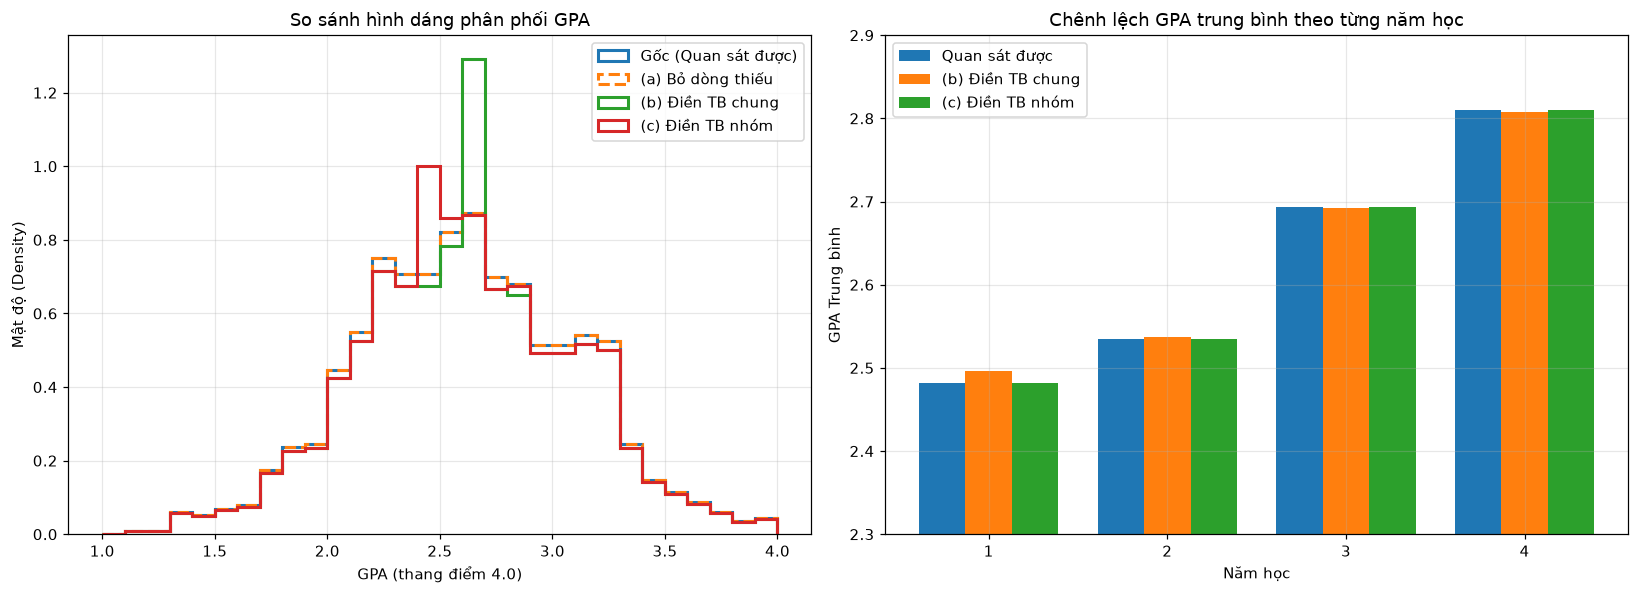

Task 4 ĐẠT.


In [16]:
# --- 4.3 Vẽ ba phân phối cùng với phân phối gốc, trên MỘT hình ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

bins = np.linspace(1.0, 4.0, 31)

# (1) Vẽ 4 đường phân phối lên ax1
# Lưu ý: original có NaN nên cần dropna() để matplotlib không báo lỗi. 
# Đường "Gốc" và "A" sẽ trùng khít nhau do chiến lược A chỉ là dropna.
ax1.hist(original.dropna(), bins=bins, histtype="step", density=True, linewidth=2, label="Gốc (Quan sát được)")
ax1.hist(A, bins=bins, histtype="step", density=True, linewidth=2, linestyle="--", label="(a) Bỏ dòng thiếu")
ax1.hist(B, bins=bins, histtype="step", density=True, linewidth=2, label="(b) Điền TB chung")
ax1.hist(C, bins=bins, histtype="step", density=True, linewidth=2, label="(c) Điền TB nhóm")

ax1.set_xlabel("GPA (thang điểm 4.0)")
ax1.set_ylabel("Mật độ (Density)")
ax1.set_title("So sánh hình dáng phân phối GPA")
ax1.legend()

# (2) Vẽ biểu đồ cột nhóm lên ax2
x = np.arange(len(by_year))
w = 0.26

ax2.bar(x - w, by_year["quan_sat_duoc"], width=w, label="Quan sát được")
ax2.bar(x, by_year["tb_chung"], width=w, label="(b) Điền TB chung")
ax2.bar(x + w, by_year["tb_nhom"], width=w, label="(c) Điền TB nhóm")

ax2.set_ylim(2.3, 2.9)
ax2.set_xticks(x)
ax2.set_xticklabels(by_year.index)
ax2.set_xlabel("Năm học")
ax2.set_ylabel("GPA Trung bình")
ax2.set_title("Chênh lệch GPA trung bình theo từng năm học")
ax2.legend()

fig.tight_layout()

# Lưu hình ảnh
fig.savefig("tuan02_so_sanh_dien_khuyet.png", dpi=300, bbox_inches="tight")
plt.show()

assert ax1.get_xlabel() and ax1.get_ylabel() and ax1.get_title()
assert ax2.get_xlabel() and ax2.get_ylabel() and ax2.get_title()
print("Task 4 ĐẠT.")

### Kết luận của bạn

> *(Nhấp đúp để sửa.)*

1. Tỉ lệ thiếu `gpa` **không đều** giữa các năm học. Con số cụ thể: 
Tỉ lệ thiếu gpa không đều giữa các năm học: Tập trung quá nửa ở sinh viên năm 1 (10.8%), trong khi năm 2, 3, 4 tỉ lệ thiếu rất thấp (dưới 3%).
2. Nhóm thiếu nhiều nhất có GPA cao hay thấp so với các nhóm còn lại? Vì sao điều đó nguy hiểm? 
Nhóm năm 1 có GPA thấp nhất (2.48). Điều này rất nguy hiểm vì dữ liệu bị thiếu có hệ thống chứ không phải ngẫu nhiên (MNAR - Missing Not At Random).
3. Chiến lược (a) làm gì với **thành phần mẫu**? Nhìn tỷ trọng sinh viên năm 1 trước/sau. 
Việc xóa dòng khiến tỷ trọng sinh viên năm 1 bị sụt giảm từ 30.08% xuống còn 28.12%. Mẫu dữ liệu bị méo lệch, không còn đại diện đúng cho tỷ lệ thật của trường.
4. Chiến lược (b) giữ nguyên trung bình chung 2.6148 — nghe có vẻ an toàn. Nhưng nhìn bảng theo từng năm: nó làm gì với trung bình của **năm 1**? 
Trung bình GPA chung của toàn trường (~2.61) cao hơn hẳn trung bình thật của năm 1 (~2.48). Việc lấy số chung đắp vào khiến GPA của nhóm năm 1 bị kéo tăng giả tạo (từ 2.4815 lên 2.4959).
5. Vì sao `std` giảm ở cả (b) và (c)? Điều đó ảnh hưởng thế nào nếu sau này bạn tính khoảng tin cậy? 
Vì ta đang chèn thêm hàng loạt các giá trị giống hệt nhau (giá trị trung bình) vào ngay tâm của phân phối, làm giảm độ phân tán của dữ liệu. Khoảng tin cậy sau này tính ra sẽ hẹp hơn mức thực tế, tạo ra cảm giác "chắc chắn ảo".
6. **Cách nào ít làm méo nhất, và vì sao?** 
Chiến lược (c) - Điền theo nhóm. Nó giữ nguyên được GPA trung bình của từng nhóm cụ thể và không làm dịch chuyển phân phối tổng thể quá nhiều như (b).
7. Theo bạn **vì sao** sinh viên năm 1 thiếu GPA nhiều hơn hẳn? Nếu giả thuyết của bạn đúng thì cách xử lý đúng nhất có còn là "điền" nữa không? 
Rất có thể do sinh viên năm 1 mới nhập học chưa lâu, chưa thi hết học kỳ hoặc chưa được cập nhật điểm lên hệ thống. Nếu đây là lý do thật, điểm GPA đơn giản là chưa tồn tại. Cách xử lý đúng nhất không phải là điền khuyết (vì không có điểm thật để mà ước lượng), mà có thể tạo một nhãn riêng (ví dụ: "Chưa có điểm") hoặc áp dụng chiến lược (a) nhưng phải ghi chú rõ về việc mẫu bị thiếu hụt sinh viên năm 1.

---
# Mở rộng (tự chọn) — dựng lại hai biểu đồ bằng Seaborn

Nếu còn thời gian: dựng lại biểu đồ **(1)** và **(2)** của Task 1 bằng Seaborn, rồi lập luận xem bản nào truyền đạt tốt hơn.

**Các bước**

1. `sns.histplot` cho phân phối GPA — thêm `hue` để tách theo `nam_hoc`. Đây là thứ matplotlib thuần làm được nhưng tốn khoảng mười dòng.
2. `sns.boxplot` cho GPA theo khoa.
3. Dùng `palette="colorblind"` — khoảng 8% nam giới bị mù màu đỏ-lục, và bảng màu mặc định không an toàn.
4. Vẫn phải đặt lại nhãn trục: **Seaborn đặt tên cột làm nhãn**, mà `gpa` hay `khoa` không phải là nhãn cho người đọc.

**Kết quả mong đợi.** Hai biểu đồ, lưu ở `tuan02_seaborn.png`, 300 dpi. Seaborn sẽ in một `MatplotlibDeprecationWarning` về tham số `vert` — đó là warning nội bộ của seaborn 0.13 với matplotlib 3.11, vô hại.

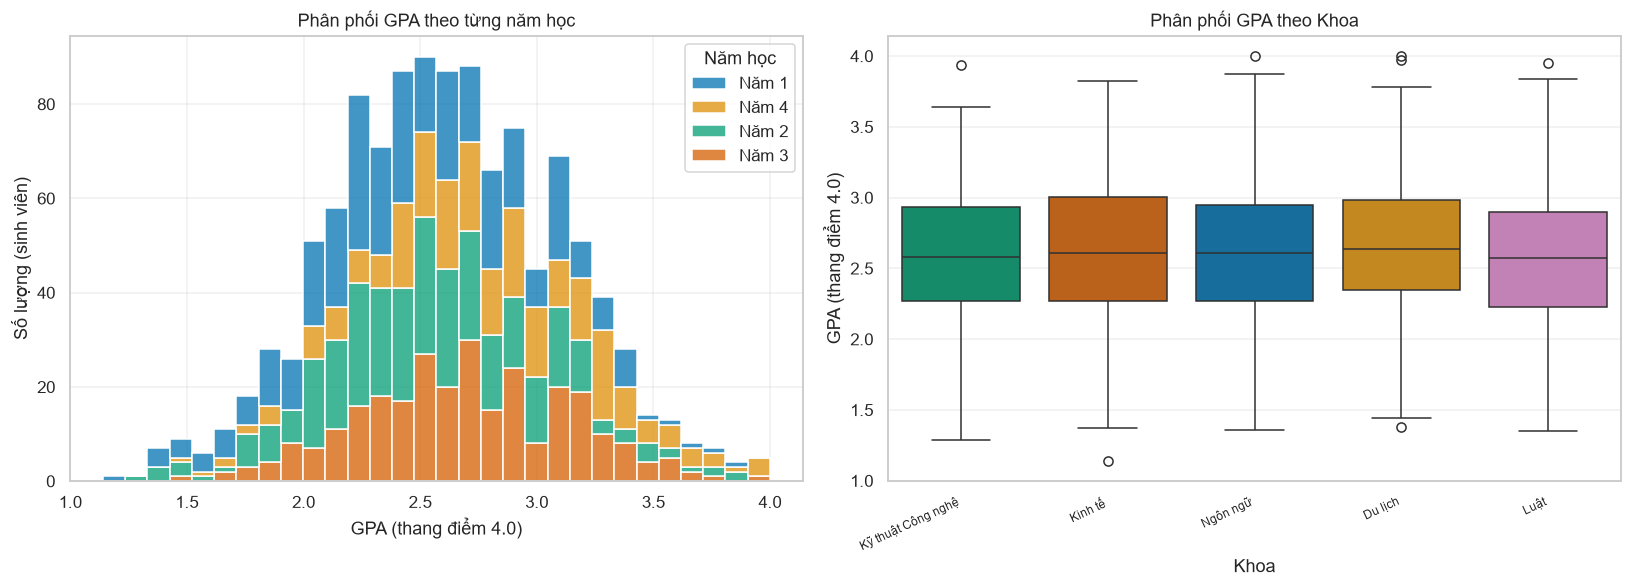

In [17]:
# --- Mở rộng (tự chọn): dựng lại biểu đồ (1) và (2) của Task 1 bằng Seaborn ---
# Lưu ý: seaborn 0.13 + matplotlib 3.11 sẽ in một MatplotlibDeprecationWarning về
# tham số `vert` ở boxplot. Đó là warning nội bộ của seaborn, vô hại, không phải lỗi của bạn.
sns.set_theme(style="whitegrid")
fig, (axa, axb) = plt.subplots(1, 2, figsize=(15, 5.5))

# (1) Vẽ Histogram phân phối GPA bằng Seaborn
# Gợi ý: tạo nhãn dạng chuỗi cho năm học để hue không bị hiểu là biến liên tục
sv_gpa = sv.dropna(subset=["gpa"]).copy()
sv_gpa["Năm học"] = "Năm " + sv_gpa["nam_hoc"].astype(str)

sns.histplot(
    data=sv_gpa, 
    x="gpa", 
    hue="Năm học", 
    bins=30, 
    multiple="stack",
    palette="colorblind", 
    ax=axa
)
axa.set_xlabel("GPA (thang điểm 4.0)")
axa.set_ylabel("Số lượng (sinh viên)")
axa.set_title("Phân phối GPA theo từng năm học")

# (2) Vẽ Boxplot GPA theo khoa bằng Seaborn
# Xác định thứ tự khoa giống Task 1 (từ khoa đông nhất đến ít nhất)
order_khoa = sv["khoa"].value_counts().index

sns.boxplot(
    data=sv, 
    x="khoa", 
    y="gpa", 
    order=order_khoa, 
    hue="khoa",
    palette="colorblind", 
    legend=False, 
    ax=axb
)
axb.set_xlabel("Khoa")
axb.set_ylabel("GPA (thang điểm 4.0)")
axb.set_title("Phân phối GPA theo Khoa")
plt.setp(axb.get_xticklabels(), rotation=25, ha="right", fontsize=8)

fig.tight_layout()
fig.savefig("tuan02_seaborn.png", dpi=300, bbox_inches="tight")
plt.show()

sns.set_theme(style="white")     # trả lại mặc định để không ảnh hưởng ô khác

### Bản nào truyền đạt tốt hơn?

> *(Nhấp đúp để sửa. Đừng trả lời "Seaborn đẹp hơn" — hãy nói **bản nào giúp người đọc trả lời câu hỏi nhanh hơn**, và đánh đổi là gì.)*

1. Bản Seaborn cho bạn thêm thông tin gì mà bản matplotlib ở Task 1 không có? 
Bản Seaborn cung cấp thông tin phân rã chi tiết của GPA theo từng năm học (thông qua tham số hue tạo thành các lớp xếp chồng multiple="stack"). Nhờ màu sắc, ta thấy được sự đóng góp của sinh viên năm 1, 2, 3, 4 vào từng cột điểm cụ thể.
2. Có thông tin nào bản matplotlib thể hiện rõ hơn không? 
Bản matplotlib thể hiện rõ con số thống kê cơ bản trên Boxplot hơn, cụ thể là việc vẽ thêm điểm trung bình (mean - thông qua showmeans=True tạo ra hình tam giác xanh). Ở Seaborn, ta chỉ thấy đường trung vị (median).
3. Bao nhiêu dòng code mỗi bản? Đánh đổi giữa số dòng và khả năng kiểm soát nằm ở đâu? 
Mỗi bản Seaborn tốn khoảng 1-2 dòng gọi hàm chính (sns.histplot hoặc sns.boxplot), ngắn hơn đáng kể so với matplotlib. Đánh đổi lại, matplotlib cho phép can thiệp sâu vào từng thành phần nhỏ nhất (như việc tự tay trích xuất data cho từng khoa rồi nhét vào list, thêm điểm mean), trong khi Seaborn hướng đến cú pháp khai báo (chỉ cần chỉ định cột dữ liệu, nó tự làm phần còn lại).
4. Nếu phải đưa một trong hai vào báo cáo gửi Ban Giám hiệu, bạn chọn bản nào, vì sao? 
Mình chọn bản Seaborn. Lý do là bảng màu colorblind rất an toàn cho mọi đối tượng độc giả, cộng thêm tính năng stack trên Histogram giúp Ban Giám hiệu trả lời nhanh được hai câu hỏi cùng lúc: "Phân phối điểm của toàn trường ra sao?" và "Tỷ trọng của từng khóa học trong phổ điểm đó như thế nào?".

---
# Danh sách kiểm tra trước khi nộp

Chạy **Kernel → Restart Kernel and Run All Cells** một lần cuối. Nếu có ô nào lỗi, notebook chưa nộp được.

**Tệp nộp**

- [x] `Tuan02_ThucHanh_VI.ipynb` — chạy hết từ trên xuống, không ô nào lỗi
- [x] `tuan02_6bieudo.png` — bảng 6 biểu đồ, 300 dpi (~0,9 MB)
- [x] `banhang_sach.csv` — 900 dòng × 8 cột
- [x] `tuan02_so_sanh_dien_khuyet.png` — hình so sánh của Task 4

**Nội dung**

- [x] **Task 1** — đủ 6 biểu đồ; **mọi** trục có nhãn kèm đơn vị; colorbar của heatmap có nhãn; ô tự kiểm tra in `ĐẠT`
- [x] **Task 1** — đã viết 6 câu nhận định, mỗi câu nói một điều dữ liệu cho biết
- [x] **Task 2** — `profile()` trả về DataFrame, đúng 1 dòng/cột, chạy được trên cả hai tệp và cả trường hợp biên
- [x] **Task 3** — cả 8 bước chạy qua `assert`; bước 3.8 báo **0/900** dòng lệch
- [x] **Task 3** — **Nhật ký làm sạch điền đầy đủ**, mỗi dòng có lý do thật, và đã trả lời cả ba câu hỏi cuối
- [x] **Task 3** — đã viết lập luận cho ba quyết định: ngày `31/02`, hai cột thiếu, bảy dòng ngoại lai
- [x] **Task 4** — đã đo tỉ lệ thiếu theo `nam_hoc` **trước khi** điền; có bảng so sánh theo từng năm; có kết luận nêu rõ cách nào ít méo nhất và vì sao

**Hai câu tự hỏi trước khi bấm nộp**

1. Nếu xóa hết kết quả và gửi notebook cho bạn cùng lớp, người đó chạy lại có ra **đúng** những con số này không?
2. Trong nhật ký làm sạch, có dòng nào mà lý do chỉ là "để dữ liệu sạch hơn" không? Nếu có, dòng đó chưa hoàn thành.

> **Nhắc lại lần cuối.** Nhật ký làm sạch được chấm ngang với phần code. Một notebook chạy hoàn hảo nhưng không giải thích được vì sao lại quyết định như vậy thì không phải một bài phân tích — nó chỉ là một chuỗi thao tác.

LINK GITHUB: 
https://github.com/Anh-Thu12/Tuan01_ThucHanh_AI

HỌ VÀ TÊN:
Hồ Ngọc Anh Thư

MSSV: 
2305CT0697